Ejer1 centroides

Objeto: Área = 0.50px² (0.00cm²), Perímetro = 8.24px (0.22cm)
Objeto: Área = 0.00px² (0.00cm²), Perímetro = 2.00px (0.05cm)
Objeto: Área = 0.00px² (0.00cm²), Perímetro = 0.00px (0.00cm)
Objeto: Área = 0.00px² (0.00cm²), Perímetro = 4.00px (0.11cm)
Objeto: Área = 0.00px² (0.00cm²), Perímetro = 2.00px (0.05cm)
Objeto: Área = 0.50px² (0.00cm²), Perímetro = 3.41px (0.09cm)
Objeto: Área = 0.00px² (0.00cm²), Perímetro = 0.00px (0.00cm)
Objeto: Área = 0.00px² (0.00cm²), Perímetro = 0.00px (0.00cm)
Objeto: Área = 0.00px² (0.00cm²), Perímetro = 0.00px (0.00cm)
Objeto: Área = 0.00px² (0.00cm²), Perímetro = 0.00px (0.00cm)
Objeto: Área = 0.00px² (0.00cm²), Perímetro = 2.83px (0.07cm)
Objeto: Área = 0.00px² (0.00cm²), Perímetro = 0.00px (0.00cm)
Objeto: Área = 0.00px² (0.00cm²), Perímetro = 0.00px (0.00cm)
Objeto: Área = 0.00px² (0.00cm²), Perímetro = 2.00px (0.05cm)
Objeto: Área = 0.00px² (0.00cm²), Perímetro = 2.83px (0.07cm)
Objeto: Área = 0.00px² (0.00cm²), Perímetro = 0.00px (0.00cm)
Objeto: 

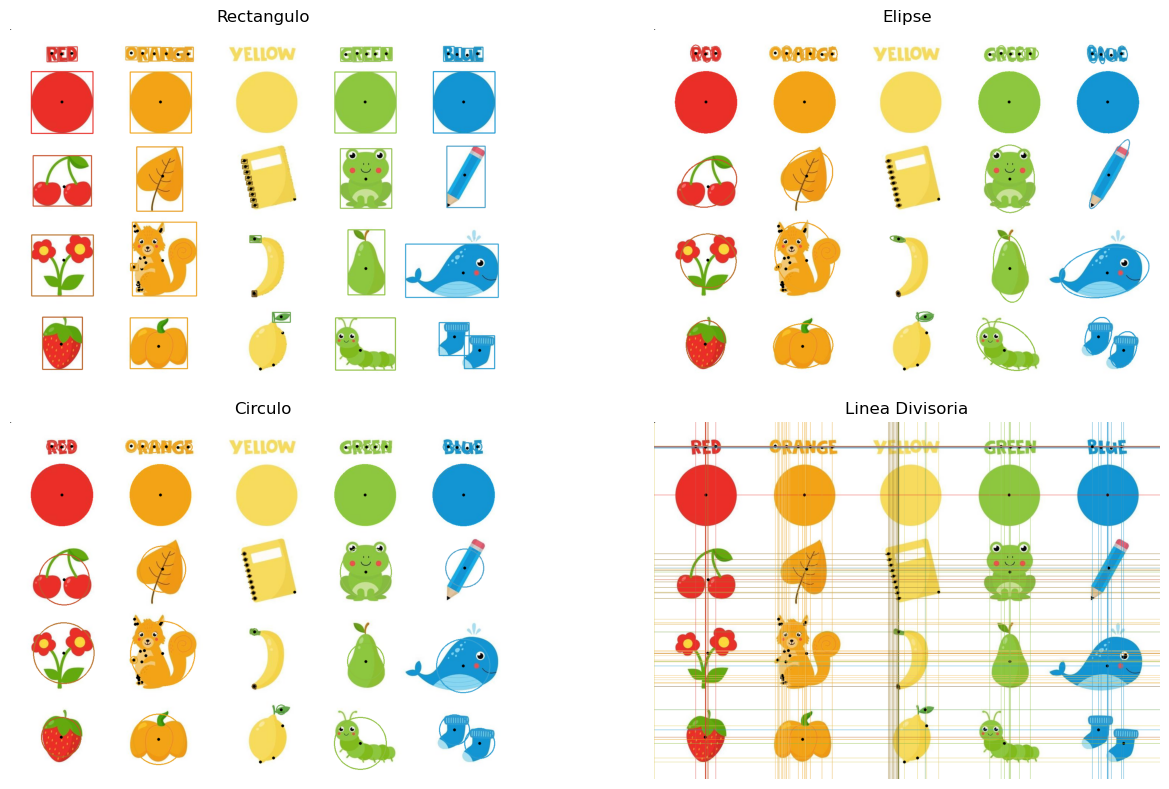

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def convertir_pixeles_a_cm(area_px, perimetro_px, pixeles_por_cm):
    area_cm2 = area_px / (pixeles_por_cm ** 2)
    perimetro_cm = perimetro_px / pixeles_por_cm
    return area_cm2, perimetro_cm

img_original = cv2.imread('colores.jpg')
img = img_original.copy()
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, bin = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)
contornos, jerarquia = cv2.findContours(bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

pixeles_por_cm = 37.79
img_subplot = [img.copy() for _ in range(4)]  

for cont in contornos:
    momento = cv2.moments(cont)
    if momento['m00'] != 0:
        cx = int(momento['m10'] / momento['m00'])
        cy = int(momento['m01'] / momento['m00'])
    else:
        cx, cy = 0, 0

    area = cv2.contourArea(cont)
    perimetro = cv2.arcLength(cont, True)

    mask = np.zeros(gray.shape, dtype=np.uint8)
    cv2.drawContours(mask, [cont], -1, 255, -1)
    mean_color = cv2.mean(img_original, mask=mask)
    color = tuple(map(int, mean_color[:3]))

    #1. rectangulo
    x, y, w, h = cv2.boundingRect(cont)
    cv2.rectangle(img_subplot[0], (x, y), (x + w, y + h), color, 2)

    #2. elipse
    if len(cont) >= 5:
        elipse = cv2.fitEllipse(cont)
        cv2.ellipse(img_subplot[1], elipse, color, 2)

    #3. circulo
    radio = int(min(w, h) / 2)
    cv2.circle(img_subplot[2], (cx, cy), radio, color, 2)

    #4. linea divisora
    cv2.line(img_subplot[3], (cx, 0), (cx, img.shape[0]), color, 1)
    cv2.line(img_subplot[3], (0, cy), (img.shape[1], cy), color, 1)

    for i in range(4):
        cv2.circle(img_subplot[i], (cx, cy), 4, (0, 0, 0), -1)

    area_cm2, perimetro_cm = convertir_pixeles_a_cm(area, perimetro, pixeles_por_cm)
    print(f'Objeto: Área = {area:.2f}px² ({area_cm2:.2f}cm²), Perímetro = {perimetro:.2f}px ({perimetro_cm:.2f}cm)')

titulos = ['Rectangulo', 'Elipse', 'Circulo', 'Linea Divisoria']
plt.figure(figsize=(14, 8))
for i, (img_subplot, titulo) in enumerate(zip(img_subplot, titulos)):
    plt.subplot(2, 2, i + 1)
    plt.imshow(cv2.cvtColor(img_subplot, cv2.COLOR_BGR2RGB))
    plt.title(titulo)
    plt.axis('off')
plt.tight_layout()
plt.show()


Ejercicio 2

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
#funciones
def umbralizacion(imagen):
    ventana = 15
    f = 2
    imagen_umbral = cv2.adaptiveThreshold(imagen,255,cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, ventana, f)
    return imagen_umbral

def kernelPropio(imagen):
    kernel5x5 = np.ones((5,5),np.float32)/25
    suavizado = cv2.filter2D(imagen,-1,kernel5x5)
    return suavizado

def kernelPredef(imagen, tamKernel):
    kernel = np.ones((1,tamKernel),np.float32)/tamKernel
    imgfin = cv2.filter2D(imagen,-1,kernel)
    return imgfin


def niebla(imagen):
    if len(imagen.shape) == 2:
        imagen = cv2.cvtColor(imagen, cv2.COLOR_GRAY2BGR)
    _, mascara = cv2.threshold(cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY), 100, 255, cv2.THRESH_BINARY)
    mascara = cv2.bitwise_not(mascara)
    mascara = cv2.GaussianBlur(mascara, (21, 21), 0)
    fondo = cv2.GaussianBlur(imagen, (51, 51), 0)
    res = np.where(mascara[:, :, None] > 0, imagen, fondo)
    return res

def sobel_mejorado(img,tam_kernel=3,umbral=30):
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    suabizado = cv2.GaussianBlur(img_gray,(3,3),0)

    sobelx = cv2.Sobel(suabizado, cv2.CV_64F,1,0,ksize=tam_kernel)
    sobely = cv2.Sobel(suabizado, cv2.CV_64F,0,1,ksize=tam_kernel)

    magnitud = np.sqrt(sobelx**2+sobely**2)

    magnitud = cv2.normalize(magnitud,None,0,255,cv2.NORM_MINMAX,cv2.CV_8U)

    _,bordes = cv2.threshold(magnitud,umbral,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU) 
    kerner_morfologico = np.ones((2,2),np.uint8)
    bordes = cv2.morphologyEx(bordes,cv2.MORPH_CLOSE, kerner_morfologico)

    return bordes

def recorte(img):
    recorte = img[600:721,650:980]
    canny = cv2.Canny(recorte,100,200)
    return canny

def medir_objetos(imagen):
    img2 = imagen.copy()
    gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    _, bin = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)
    contornos, _ = cv2.findContours(bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for cont in contornos:
        area = cv2.contourArea(cont)
        perimetro = cv2.arcLength(cont, True)
        
        momento = cv2.moments(cont)
        if momento['m00'] != 0:
            cx = int(momento['m10'] / momento['m00'])
            cy = int(momento['m01'] / momento['m00'])
        else:
            cx, cy = 0, 0

        cv2.drawContours(img2, [cont], -1, (0, 255, 255), 2)
        cv2.circle(img2, (cx, cy), 5, (0, 0, 255), -1)

        cv2.putText(img2, f"A:{int(area)} P:{int(perimetro)}", (cx + 10, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 0), 1)

    return img2

def objeto_seleccionado(imagen):
    img_copy = imagen.copy()
    gray = cv2.cvtColor(img_copy, cv2.COLOR_BGR2GRAY)
    _, bin = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)
    contornos, _ = cv2.findContours(bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contornos:
        objeto = max(contornos, key=cv2.contourArea) 
        x, y, w, h = cv2.boundingRect(objeto)
        cv2.rectangle(img_copy, (x, y), (x + w, y + h), (255, 0, 255), 3) 
    return img_copy


Objeto: Área = 3.00px² (0.60cm²), Perímetro = 8.83px (3.36cm)
Objeto: Área = 0.00px² (0.60cm²), Perímetro = 0.00px (3.36cm)
Objeto: Área = 0.00px² (0.60cm²), Perímetro = 2.00px (3.36cm)
Objeto: Área = 13.00px² (0.60cm²), Perímetro = 26.49px (3.36cm)
Objeto: Área = 902820.00px² (0.60cm²), Perímetro = 4457.74px (3.36cm)
Objeto: Área = 0.00px² (0.60cm²), Perímetro = 0.00px (3.36cm)
Objeto: Área = 6.00px² (0.60cm²), Perímetro = 12.83px (3.36cm)
Objeto: Área = 96.50px² (0.60cm²), Perímetro = 41.21px (3.36cm)
Objeto: Área = 0.00px² (0.60cm²), Perímetro = 2.00px (3.36cm)
Objeto: Área = 0.50px² (0.60cm²), Perímetro = 5.41px (3.36cm)
Objeto: Área = 48.00px² (0.60cm²), Perímetro = 27.31px (3.36cm)
Objeto: Área = 75.00px² (0.60cm²), Perímetro = 39.66px (3.36cm)
Objeto: Área = 81.00px² (0.60cm²), Perímetro = 38.63px (3.36cm)
Objeto: Área = 0.00px² (0.60cm²), Perímetro = 0.00px (3.36cm)
Objeto: Área = 747.00px² (0.60cm²), Perímetro = 141.54px (3.36cm)
Objeto: Área = 0.00px² (0.60cm²), Perímetro = 6

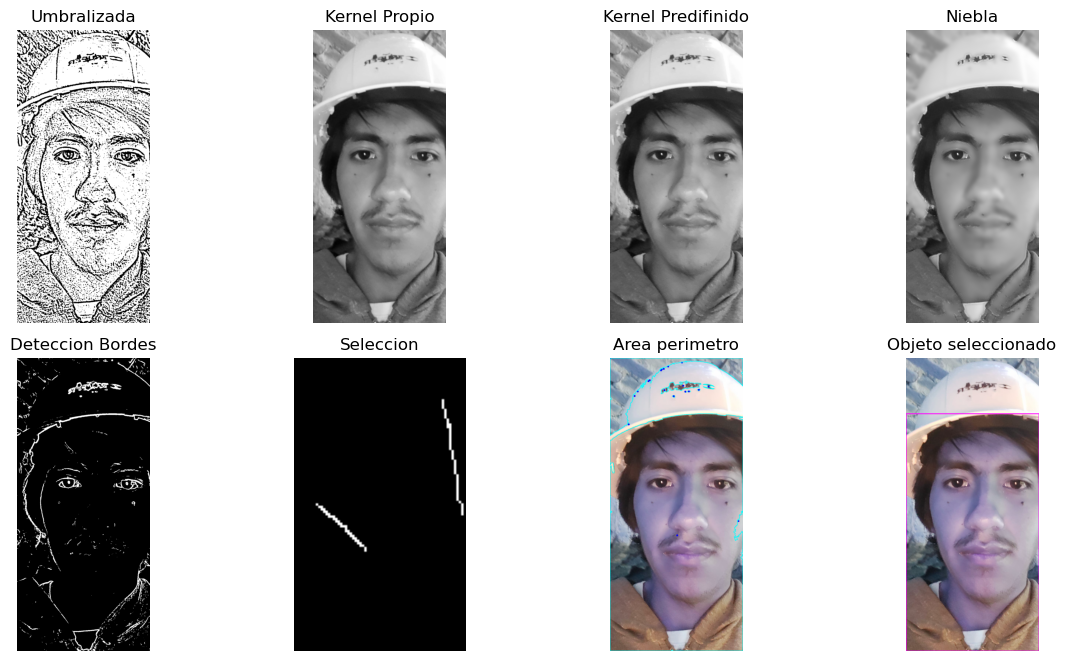

In [49]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_original = cv2.imread('Foto1.jpg')
imgGray = cv2.cvtColor(img_original,cv2.COLOR_BGR2GRAY)
imgRGB = cv2.cvtColor(img_original,cv2.COLOR_BGR2RGB)

imgUmbra = umbralizacion(imgGray)
imgKernelPro = kernelPropio(imgGray)
imgKernelPre = kernelPredef(imgGray,5)
imgNiebla = niebla(imgGray)
imgBordes = sobel_mejorado(imgRGB)
imgRecor = recorte(imgGray)
imgMedidas = medir_objetos(img_original)
ObjetoSelec = objeto_seleccionado(img_original)

plt.figure(figsize=(12, 10))

plt.subplot(3, 4, 1)
plt.imshow(imgUmbra, cmap='gray')
plt.title('Umbralizada')
plt.axis('off')

plt.subplot(3, 4, 2)
plt.imshow(imgKernelPro, cmap='gray')
plt.title('Kernel Propio')
plt.axis('off')

plt.subplot(3, 4, 3)
plt.imshow(imgKernelPre, cmap='gray')
plt.title('Kernel Predifinido')
plt.axis('off')

plt.subplot(3, 4, 4)
plt.imshow(imgNiebla, cmap='gray')
plt.title('Niebla')
plt.axis('off')

plt.subplot(3, 4, 5)
plt.imshow(imgBordes, cmap='gray')
plt.title('Deteccion Bordes')
plt.axis('off')

plt.subplot(3, 4, 6)
plt.imshow(imgRecor, cmap='gray')
plt.title('Seleccion')
plt.axis('off')

plt.subplot(3, 4, 7)
plt.imshow(imgMedidas, cmap='gray')
plt.title('Area perimetro')
plt.axis('off')

plt.subplot(3, 4, 8)
plt.imshow(ObjetoSelec, cmap='gray')
plt.title('Objeto seleccionado')
plt.axis('off')

plt.tight_layout()
plt.show()

Ejercicio 3

cantidad de objetos: 96


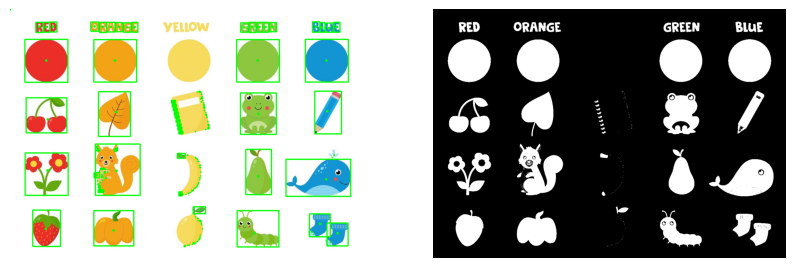

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('colores.jpg')
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

ret,bin=cv2.threshold(gray,200,255,cv2.THRESH_BINARY_INV)
contorno,jerarquia=cv2.findContours(bin,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

perimetros=[]
areas=[]

_,binario=cv2.threshold(gray,128,255,cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
borde,_ = cv2.findContours(binario,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cont = len(borde)
print(f'cantidad de objetos: {cont}')

for i in range(len(contorno)):
    cont = contorno[i]
    momento = cv2.moments(cont)
    if momento['m00']!=0:
        #centroide
        cx=int(momento['m10']/momento['m00'])
        cy=int(momento['m01']/momento['m00'])
    else:
        cx,cy = 0,0

    area = cv2.contourArea(cont)
    perimetro = cv2.arcLength(cont,True)

    perimetros.append(perimetro)
    areas.append(area)

    cv2.circle(img,(cx,cy),5,(0,255,0),-1)
    x,y,w,h = cv2.boundingRect(cont)
    cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),3)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(bin,cmap='gray')
plt.axis('off')
plt.show()


  